# Factorial ANOVA for electrocatalyst specific activity

**Question:** How do nominal Pt loading, carbon support, and Pt locality relate to SA, and do their effects depend on one another?

**Dataset:** 24 electrode tests, 12 catalyst samples, a 2 × 3 × 2 factorial layout.

**Experimental unit:** The two replicates are separate electrode tests of the same catalyst batch. All inferential calculations below are conditional on those tested batches and assume independent electrode errors with a common variance. They do not establish synthesis-to-synthesis reproducibility or causal effects of preparation factors.

Read the markdown above each code cell, predict the output, and then run the cell. Start with cells 1–9 in your first session; continue to the model after the group means and interactions make sense. The [companion guide](../docs/theory-and-walkthrough.md) gives more detail and communication examples.

## 1. Load the tools and locate the project

`pandas` handles tables, `numpy` handles numerical arrays, `scipy` supplies probability distributions, and `statsmodels` fits statistical models. `Path` makes file paths work on Windows, Linux, and macOS. The import from `analyze.py` provides reusable helpers; the central calculations are also shown explicitly below.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
from patsy import build_design_matrices
from IPython.display import display, Image

candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next(p for p in candidates if (p / 'data/catalyst_activity.csv').exists())
sys.path.insert(0, str(ROOT / 'src'))
from analyze import (
    load_data, FACTORS, LEVELS, FORMULA, TERMS, anova_table,
    manual_decomposition, cell_summary, simple_locality_effects,
    interaction_contrasts, average_effects, figures, run_analysis,
)
pd.set_option('display.max_columns', 12)

## 2. Read the observations without changing them

One row is one electrode test. We keep the supplied SA as the response. The units used in this project are inferred as µA/cm²Pt; check laboratory records before manuscript use. `head()` shows the first rows; `shape` reports rows and columns.

In [2]:
raw = pd.read_csv(ROOT / 'data/catalyst_activity.csv')
print('Rows and columns:', raw.shape)
display(raw.head())

Rows and columns: (24, 8)


,Sample,Loading,Locality,Replicate,ECSA_CO,ECSA_TEM,MA,SA
0,Pt_OUT-15/FCX-Disordered,14.60,OUT,1,68.5,131.9,23.2,33.9
1,Pt_OUT-15/FCX-Disordered,14.60,OUT,2,61.6,131.9,17.9,29.0
2,Pt_IN-15/FCX-Disordered,16.08,IN,1,72.0,131.9,17.8,24.7
3,Pt_IN-15/FCX-Disordered,16.08,IN,2,78.1,131.9,23.6,30.4
4,Pt_OUT-40/FCX-Disordered,45.01,OUT,1,62.3,124.2,49.1,78.8


## 3. Create factors from the sample identifiers

`Loading` contains the measured Pt percentage, but the factorial design compares the nominal **15** and **40** groups. We extract the nominal group from `Sample`. Carbon names are also encoded in `Sample`. `C(...)` in the later model will make these variables categorical.

Do not define the groups using a guessed numerical cutoff. The sample names tell us the intended experimental settings.

In [3]:
df = raw.copy()
df['Loading_level'] = df['Sample'].str.extract(r'-(15|40)/', expand=False)
df['Carbon'] = df['Sample'].str.split('/FCX-').str[1].replace({'B': 'FCX-B'})
for name, levels in zip(FACTORS, LEVELS):
    df[name] = pd.Categorical(df[name], categories=levels, ordered=True)
display(df[['Sample', 'Loading', 'Loading_level', 'Carbon', 'Locality', 'SA']].head())

,Sample,Loading,Loading_level,Carbon,Locality,SA
0,Pt_OUT-15/FCX-Disordered,14.60,15,Disordered,OUT,33.9
1,Pt_OUT-15/FCX-Disordered,14.60,15,Disordered,OUT,29.0
2,Pt_IN-15/FCX-Disordered,16.08,15,Disordered,IN,24.7
3,Pt_IN-15/FCX-Disordered,16.08,15,Disordered,IN,30.4
4,Pt_OUT-40/FCX-Disordered,45.01,40,Disordered,OUT,78.8


## 4. Check the layout before fitting anything

`groupby` places rows with the same factor combination together. `size()` counts observations in each cell. Every count should be 2. The source-code validator also checks missing values, duplicated sample/replicate IDs, finite positive measurements, sample-label consistency, and complete factor combinations. It raises an error instead of quietly dropping rows.

Replicate 1 in one sample is not automatically paired with replicate 1 in another sample. A pairing or day/block effect would require collection metadata.

In [4]:
validated = load_data(ROOT / 'data/catalyst_activity.csv')
counts = df.groupby(FACTORS, observed=False).size().rename('n')
display(counts.unstack('Locality'))
assert len(df) == 24
assert len(counts) == 12 and counts.eq(2).all()
assert df[FACTORS + ['SA']].notna().all().all()
pd.testing.assert_series_equal(df['SA'], validated['SA'])
print('Complete balanced layout: 12 cells x 2 electrode tests.')

Complete balanced layout: 12 cells x 2 electrode tests.


Locality                   IN  OUT
Loading_level Carbon              
15            Disordered    2    2
              Graphitized   2    2
              FCX-B         2    2
40            Disordered    2    2
              Graphitized   2    2
              FCX-B         2    2

## 5. Look at sample means and electrode variation

The mean estimates activity for a tested sample. The sample SD describes dispersion of its two electrode tests. With n = 2, each SD is based on only one degree of freedom, so it is an unstable estimate of variability. Do not mistake SD for uncertainty in the mean or for synthesis reproducibility.

In [5]:
summary = df.groupby(FACTORS, observed=False)['SA'].agg(n='size', mean='mean', sd='std')
display(summary.round(3))

n    mean     sd
Loading_level Carbon      Locality                  
15            Disordered  IN        2  27.550  4.031
                          OUT       2  31.450  3.465
              Graphitized IN        2  31.250  2.192
                          OUT       2  39.890  5.742
              FCX-B       IN        2  33.700  5.374
                          OUT       2  40.300  1.131
40            Disordered  IN        2  55.700  5.091
                          OUT       2  78.150  0.919
              Graphitized IN        2  59.850  4.738
                          OUT       2  64.200  3.677
              FCX-B       IN        2  55.235  0.375
                          OUT       2  72.600  2.687

## 6. Calculate main effects by averaging

A main effect averages across the other factors. Equal cell counts make ordinary means equal to equal-weight marginal means. The loading difference asks how the 40 group compares with the 15 group **on average**. The locality difference is OUT minus IN, also averaged.

In [6]:
loading_means = df.groupby('Loading_level', observed=False)['SA'].mean()
locality_means = df.groupby('Locality', observed=False)['SA'].mean()
carbon_means = df.groupby('Carbon', observed=False)['SA'].mean()
display(loading_means, locality_means, carbon_means)
print('Average 40 - 15:', loading_means['40'] - loading_means['15'])
print('Average OUT - IN:', locality_means['OUT'] - locality_means['IN'])

Average 40 - 15: 30.26583333333334
Average OUT - IN: 10.550833333333337


Loading_level
15    34.023333
40    64.289167
Name: SA, dtype: float64

Locality
IN     43.880833
OUT    54.431667
Name: SA, dtype: float64

Carbon
Disordered     48.21250
Graphitized    48.79750
FCX-B          50.45875
Name: SA, dtype: float64

## 7. Find the simple effects: OUT minus IN within each setting

`unstack` moves IN and OUT into separate columns. Subtraction then calculates a directly interpretable contrast. These are **simple effects** because loading and carbon are held at particular levels.

In [7]:
means = df.groupby(['Carbon', 'Loading_level', 'Locality'], observed=False)['SA'].mean()
locality_by_setting = means.unstack('Locality')
locality_by_setting['OUT_minus_IN'] = locality_by_setting['OUT'] - locality_by_setting['IN']
display(locality_by_setting.round(3))

Locality                       IN    OUT  OUT_minus_IN
Carbon      Loading_level                             
Disordered  15             27.550  31.45         3.900
            40             55.700  78.15        22.450
Graphitized 15             31.250  39.89         8.640
            40             59.850  64.20         4.350
FCX-B       15             33.700  40.30         6.600
            40             55.235  72.60        17.365

## 8. Calculate an interaction by hand

For Disordered carbon, OUT − IN changes from 3.90 at 15 wt% to 22.45 at 40 wt%. The interaction contrast is the **difference of differences**:

\[
(OUT-IN)_{40}-(OUT-IN)_{15}=22.45-3.90=18.55.
\]

The three-factor question is whether this change itself differs across the three carbons. It is not enough to say that one simple comparison is significant and another is not; we must compare the differences directly.

In [8]:
gaps = locality_by_setting['OUT_minus_IN'].unstack('Loading_level')
gaps['gap_change_40_minus_15'] = gaps['40'] - gaps['15']
display(gaps.round(3))
assert np.isclose(gaps.loc['Disordered', 'gap_change_40_minus_15'], 18.55)

Loading_level,15,40,gap_change_40_minus_15
Carbon,,,
Disordered,3.90,22.450,18.550
Graphitized,8.64,4.350,-4.290
FCX-B,6.60,17.365,10.765


## 9. Fit the full factorial model

The model contains the grand mean, three main effects, three two-factor interactions, and the three-factor interaction:

\[
SA=\mu+L+C+P+LC+LP+CP+LCP+\epsilon.
\]

In the formula, `~` means modeled as a function of; `C(..., Sum)` means categorical with sum-to-zero coding; `*` expands into main effects and all interactions. `A:B` would mean just an interaction. OLS minimizes squared residuals.

This full model has 12 parameters for 12 cell means. It fits the observed cell means exactly, leaving the electrode deviations as residuals. That is appropriate for this descriptive factorial decomposition, but a high R² is not evidence of prediction on new batches.

In [9]:
model = ols(
    'SA ~ C(Loading_level, Sum) * C(Carbon, Sum) * C(Locality, Sum)',
    data=df,
).fit()
print('Observations:', int(model.nobs))
print('Parameters / design rank:', np.linalg.matrix_rank(model.model.exog))
print('Residual degrees of freedom:', int(model.df_resid))
print('Descriptive R-squared:', round(model.rsquared, 4))
cell_means_for_rows = df.groupby(FACTORS, observed=False)['SA'].transform('mean')
np.testing.assert_allclose(model.fittedvalues, cell_means_for_rows)

Observations: 24
Parameters / design rank: 12
Residual degrees of freedom: 12
Descriptive R-squared: 0.9755


## 10. Ask ANOVA for the joint tests

Type III tests each term in the full model. Sum contrasts make the main-effect hypotheses equal-weight marginal comparisons in this balanced complete design. Omitting `Sum` changes the coding and can change what a Type III main-effect test asks. The intercept test is omitted because a zero grand mean is not our research question.

Carbon has 2 df; loading and locality each have 1 df. Interaction df multiply. The residual has 12 df. Ordinary coefficient p-values from `model.summary()` are not a substitute for these joint tests.

In [10]:
anova = anova_lm(model, typ=3).drop(index='Intercept')
anova = anova.rename(index=TERMS)
anova['mean_sq'] = anova['sum_sq'] / anova['df']
display(anova[['sum_sq', 'df', 'mean_sq', 'F', 'PR(>F)']])

,sum_sq,df,mean_sq,F,PR(>F)
Loading,5496.124004,1.0,5496.124004,396.658669,1.464782e-10
Carbon,21.726975,2.0,10.863487,0.784025,4.786114e-01
Locality,667.920504,1.0,667.920504,48.204236,1.554031e-05
Loading x Carbon,153.974908,2.0,76.987454,5.556232,1.958890e-02
Loading x Locality,104.375104,1.0,104.375104,7.532816,1.777931e-02
Carbon x Locality,50.771408,2.0,25.385704,1.832102,2.021331e-01
Loading x Carbon x Locality,134.820808,2.0,67.410404,4.865051,2.836070e-02
Residual,166.272650,12.0,13.856054,NaN,NaN


## 11. Reconstruct the denominator of every F-test

Residual SS sums squared deviations from cell means. Error MS is residual SS divided by 12. Its square root estimates the conditional within-sample electrode SD under the common-variance assumption.

For a two-observation sample with values 33.9 and 29.0, the mean is 31.45, and its error SS contribution is 12.005. Do this for all cells and add them.

In [11]:
first_pair = np.array([33.9, 29.0])
print('First pair mean:', first_pair.mean())
print('First pair residual SS:', ((first_pair - first_pair.mean()) ** 2).sum())
ss_error = ((df['SA'] - cell_means_for_rows) ** 2).sum()
df_error = len(df) - len(summary)
ms_error = ss_error / df_error
print('Residual SS:', ss_error)
print('Residual df:', df_error)
print('Residual MS:', ms_error)
print('Residual SD:', np.sqrt(ms_error))
np.testing.assert_allclose(ms_error, model.mse_resid)

First pair mean: 31.45
First pair residual SS: 12.004999999999994
Residual SS: 166.27264999999997
Residual df: 12
Residual MS: 13.856054166666665
Residual SD: 3.7223721155557064


## 12. Reconstruct the loading F-test

Loading SS is the sum of squared deviations of the two marginal means from the grand mean, multiplied by 12 observations per loading group. Divide by its 1 df, then divide by error MS. `stats.f.sf` is the right-tail probability under the null F distribution.

The p-value assumes the tested null and error model. It is not the probability that the null is true or that the effect is scientifically important.

In [12]:
grand_mean = df['SA'].mean()
ss_loading = 12 * ((loading_means - grand_mean) ** 2).sum()
f_loading = (ss_loading / 1) / ms_error
p_loading = stats.f.sf(f_loading, dfn=1, dfd=df_error)
print('Loading SS:', ss_loading)
print('Loading F:', f_loading)
print('Loading p:', p_loading)
np.testing.assert_allclose(ss_loading, anova.loc['Loading', 'sum_sq'])
np.testing.assert_allclose(p_loading, anova.loc['Loading', 'PR(>F)'])

Loading SS: 5496.124004166669
Loading F: 396.65866905952385
Loading p: 1.464781646746054e-10


## 13. Verify the whole SS partition independently

The helper below uses only cell means, lower-order effect subtraction, and NumPy arithmetic. It does not use regression to compute the seven effect SS. This checks that the formula model corresponds to the intended balanced factorial decomposition.

In [13]:
manual = manual_decomposition(df)
verification = anova[['sum_sq', 'df']].join(manual)
verification['SS_difference'] = verification['sum_sq'] - verification['SS_manual']
display(verification)
np.testing.assert_allclose(verification['sum_sq'], verification['SS_manual'], atol=1e-9)
ss_total = ((df['SA'] - grand_mean) ** 2).sum()
np.testing.assert_allclose(anova['sum_sq'].sum(), ss_total)
print('All eight components add to total centered SS:', ss_total)

All eight components add to total centered SS: 6795.9863625


,sum_sq,df,SS_manual,df_manual,SS_difference
Loading,5496.124004,1.0,5496.124004,1,-1.818989e-12
Carbon,21.726975,2.0,21.726975,2,-3.694822e-13
Locality,667.920504,1.0,667.920504,1,-4.547474e-13
Loading x Carbon,153.974908,2.0,153.974908,2,-2.984279e-12
Loading x Locality,104.375104,1.0,104.375104,1,4.263256e-14
Carbon x Locality,50.771408,2.0,50.771408,2,5.258016e-13
Loading x Carbon x Locality,134.820808,2.0,134.820808,2,6.821210e-13
Residual,166.272650,12.0,166.272650,12,-2.842171e-14


## 14. Separate raw p-values from multiple-testing adjustment

There are seven omnibus questions. We show the raw p-values and Holm adjustment over those seven tests. This is an exploratory analysis policy, not a preregistered plan. Holm's adjustment applies to the named family; it does not make all analyses in this notebook one globally controlled experiment.

Here loading and locality remain below 0.05 after adjustment, while three interaction p-values move from roughly 0.018–0.028 to 0.089. The interaction patterns are leads to investigate, not established generalizable effects.

In [14]:
omnibus = anova.drop(index='Residual')[['F', 'PR(>F)']].copy()
omnibus['p_holm_7_terms'] = multipletests(omnibus['PR(>F)'], method='holm')[1]
display(omnibus)

,F,PR(>F),p_holm_7_terms
Loading,396.658669,1.464782e-10,1.025347e-09
Carbon,0.784025,4.786114e-01,4.786114e-01
Locality,48.204236,1.554031e-05,9.324187e-05
Loading x Carbon,5.556232,1.958890e-02,8.889656e-02
Loading x Locality,7.532816,1.777931e-02,8.889656e-02
Carbon x Locality,1.832102,2.021331e-01,4.042663e-01
Loading x Carbon x Locality,4.865051,2.836070e-02,8.889656e-02


## 15. Quantify effect size without confusing denominators

Eta squared divides each term SS by total SS. Partial eta squared divides it by that term SS plus residual SS. Loading is about 80.9% by eta squared and 97.1% by partial eta squared. Neither is a causal percentage of the physical mechanism. Partial eta squared values are not additive.

The most directly interpretable effect sizes here remain differences in SA units.

In [15]:
effect_sizes = anova.drop(index='Residual')[['sum_sq']].copy()
effect_sizes['eta_squared'] = effect_sizes['sum_sq'] / ss_total
effect_sizes['partial_eta_squared'] = effect_sizes['sum_sq'] / (effect_sizes['sum_sq'] + ss_error)
display(effect_sizes.round(4))
display(average_effects(model))

,sum_sq,eta_squared,partial_eta_squared
Loading,5496.1240,0.8087,0.9706
Carbon,21.7270,0.0032,0.1156
Locality,667.9205,0.0983,0.8007
Loading x Carbon,153.9749,0.0227,0.4808
Loading x Locality,104.3751,0.0154,0.3856
Carbon x Locality,50.7714,0.0075,0.2339
Loading x Carbon x Locality,134.8208,0.0198,0.4478


,factor,contrast,estimate,se,t,df,p_raw,ci95_low_pointwise,ci95_high_pointwise
0,Loading_level,40 - 15,30.265833,1.519652,19.916292,12.0,1.464782e-10,26.954796,33.576871
1,Locality,OUT - IN,10.550833,1.519652,6.942927,12.0,1.554031e-05,7.239796,13.861871


## 16. Build one confidence interval by hand

For Disordered at 40 wt%, estimate OUT − IN. With two electrodes per cell and a common variance,

\[
SE=\sqrt{MS_E(1/2+1/2)}.
\]

A pointwise 95% CI is estimate ± t(0.975,12) × SE. It quantifies uncertainty relative to electrode error, conditional on the tested batches. It is not a prediction interval for a new electrode or new synthesis.

In [16]:
estimate = locality_by_setting.loc[('Disordered', '40'), 'OUT_minus_IN']
se_difference = np.sqrt(ms_error * (1/2 + 1/2))
t_critical = stats.t.ppf(0.975, df_error)
ci = (estimate - t_critical * se_difference, estimate + t_critical * se_difference)
print(f'OUT - IN = {estimate:.3f}; SE = {se_difference:.3f}; 95% CI = {ci}')

OUT - IN = 22.450; SE = 3.722; 95% CI = (np.float64(14.339647877831688), np.float64(30.560352122168318))


## 17. Express the same comparison as a model contrast

This is an optional bridge to reusable analysis code. The formula produces a design matrix: each row encodes a factor combination. Subtract the IN row from the OUT row to create a contrast vector `L`. Then `L @ coefficients` is the desired difference. `t_test(L)` calculates its estimate, standard error, interval, and two-sided p-value using the fitted covariance matrix.

The helper for all six contrasts repeats exactly this operation.

In [17]:
comparison = pd.DataFrame({
    'Loading_level': ['40', '40'],
    'Carbon': ['Disordered', 'Disordered'],
    'Locality': ['OUT', 'IN'],
})
design_rows = np.asarray(build_design_matrices([model.model.data.design_info], comparison)[0])
L = design_rows[0] - design_rows[1]
test = model.t_test(L)
display(test.summary_frame())
np.testing.assert_allclose(np.asarray(test.effect).item(), estimate)
np.testing.assert_allclose(test.conf_int().ravel(), ci)

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.
c0,22.45,3.722372,6.0311,0.000059,14.339648,30.560352


## 18. Compare locality within each carbon/loading combination

Six planned-by-structure comparisons are more interpretable than every possible pair among 12 samples. We adjust across these six p-values with Holm. The reported intervals remain pointwise, not simultaneous; a pointwise CI can exclude zero while the adjusted p-value exceeds 0.05.

In [18]:
locality_effects = simple_locality_effects(model)
display(locality_effects.round(5))

,Carbon,Loading_level,contrast,estimate,se,t,df,p_raw,ci95_low_pointwise,ci95_high_pointwise,p_holm_6_comparisons
0,Disordered,15,OUT - IN,3.900,3.72237,1.04772,12.0,0.31541,-4.21035,12.01035,0.53051
1,Disordered,40,OUT - IN,22.450,3.72237,6.03110,12.0,0.00006,14.33965,30.56035,0.00036
2,Graphitized,15,OUT - IN,8.640,3.72237,2.32110,12.0,0.03869,0.52965,16.75035,0.15476
3,Graphitized,40,OUT - IN,4.350,3.72237,1.16861,12.0,0.26525,-3.76035,12.46035,0.53051
4,FCX-B,15,OUT - IN,6.600,3.72237,1.77306,12.0,0.10158,-1.51035,14.71035,0.30473
5,FCX-B,40,OUT - IN,17.365,3.72237,4.66504,12.0,0.00055,9.25465,25.47535,0.00273


## 19. Quantify the differences of differences

Weights `[1, -1, -1, 1]` applied to `[OUT40, IN40, OUT15, IN15]` produce the interaction contrast within each carbon. The three comparisons form a separate exploratory Holm family. A significant contrast within one carbon does not automatically establish that it differs from the contrast in another carbon; the three-factor omnibus test addresses that broader comparison.

In [19]:
interaction_effects = interaction_contrasts(model)
display(interaction_effects.round(5))

,Carbon,contrast,estimate,se,t,df,p_raw,ci95_low_pointwise,ci95_high_pointwise,p_holm_3_comparisons
0,Disordered,(OUT-IN)40 - (OUT-IN)15,18.550,5.26423,3.52378,12.0,0.00419,7.08023,30.01977,0.01258
1,Graphitized,(OUT-IN)40 - (OUT-IN)15,-4.290,5.26423,-0.81493,12.0,0.43099,-15.75977,7.17977,0.43099
2,FCX-B,(OUT-IN)40 - (OUT-IN)15,10.765,5.26423,2.04493,12.0,0.06344,-0.70477,22.23477,0.12687


## 20. Plot the estimates and their uncertainty

Crosses are the individual electrode observations. Circles are sample means. Error bars are pointwise 95% intervals from pooled electrode error with 12 residual df. These are not mean ± SD bars. Nonparallel lines identify observed interaction patterns, whose uncertainty and experimental scope we have already examined.

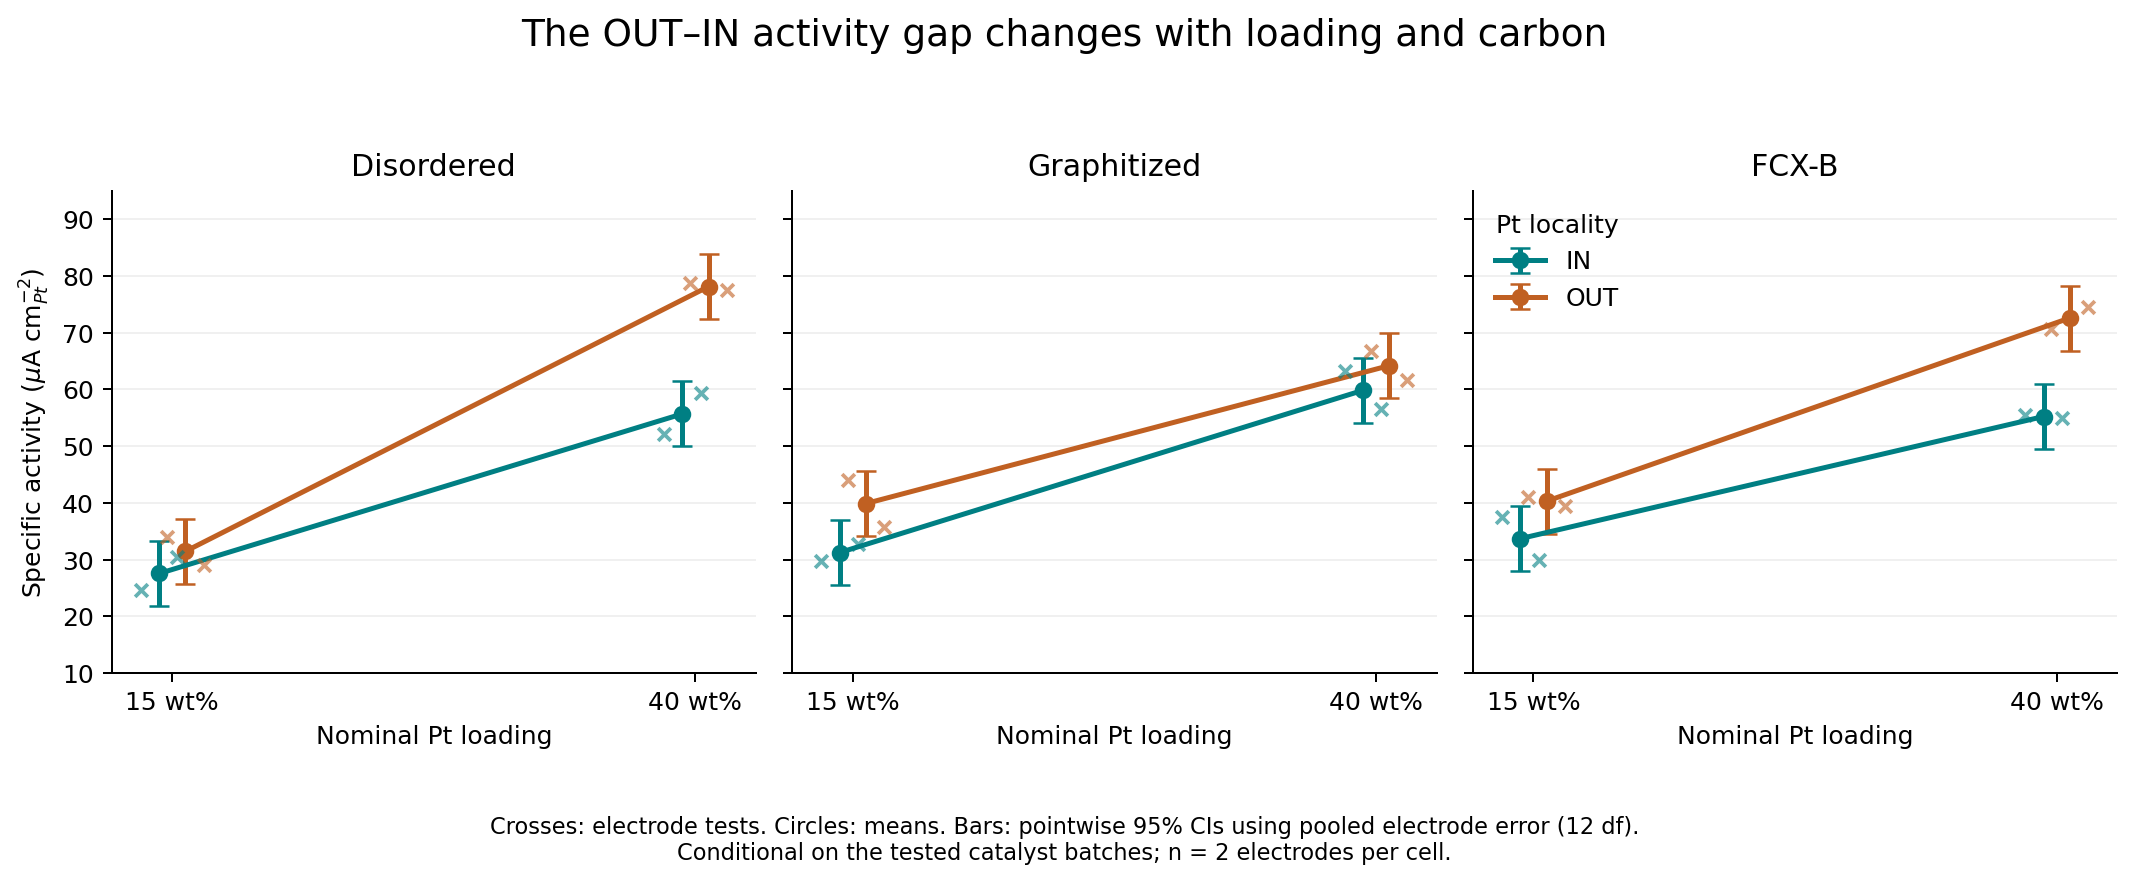

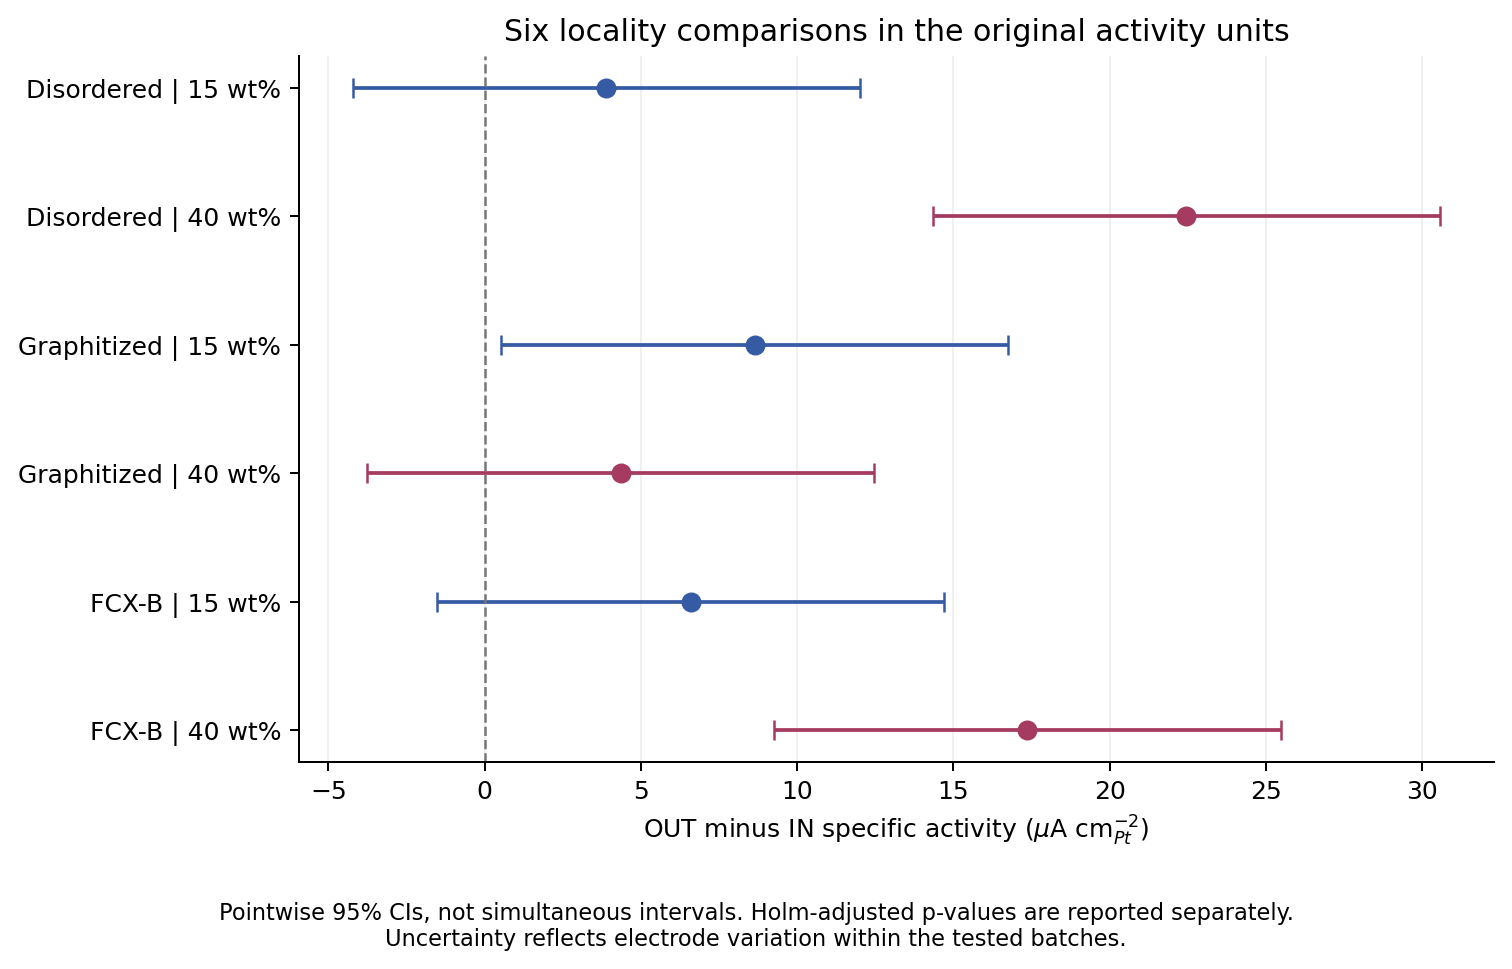

In [20]:
cells_with_ci = cell_summary(df, model)
plot_path = ROOT / 'outputs/figures'
figures(df, model, cells_with_ci, locality_effects, plot_path)
display(Image(filename=str(plot_path / 'interaction_plot.png')))
display(Image(filename=str(plot_path / 'locality_effects.png')))

## 21. Inspect residuals without treating a diagnostic as proof

Classical ANOVA's exact small-sample tests assume normal, independent conditional errors with a common variance. The pooled SA values do not need to form one normal distribution.

With two electrodes per sample, residuals come in opposite pairs by construction. A symmetric Q–Q plot is therefore partly mechanical. A median-centered Levene test across two-observation cells is also degenerate because both absolute deviations within each cell are identical. We use descriptive plots and experimental reasoning, not a normality-test pass/fail gate. These diagnostics cannot establish independence or estimate missing batch variation.

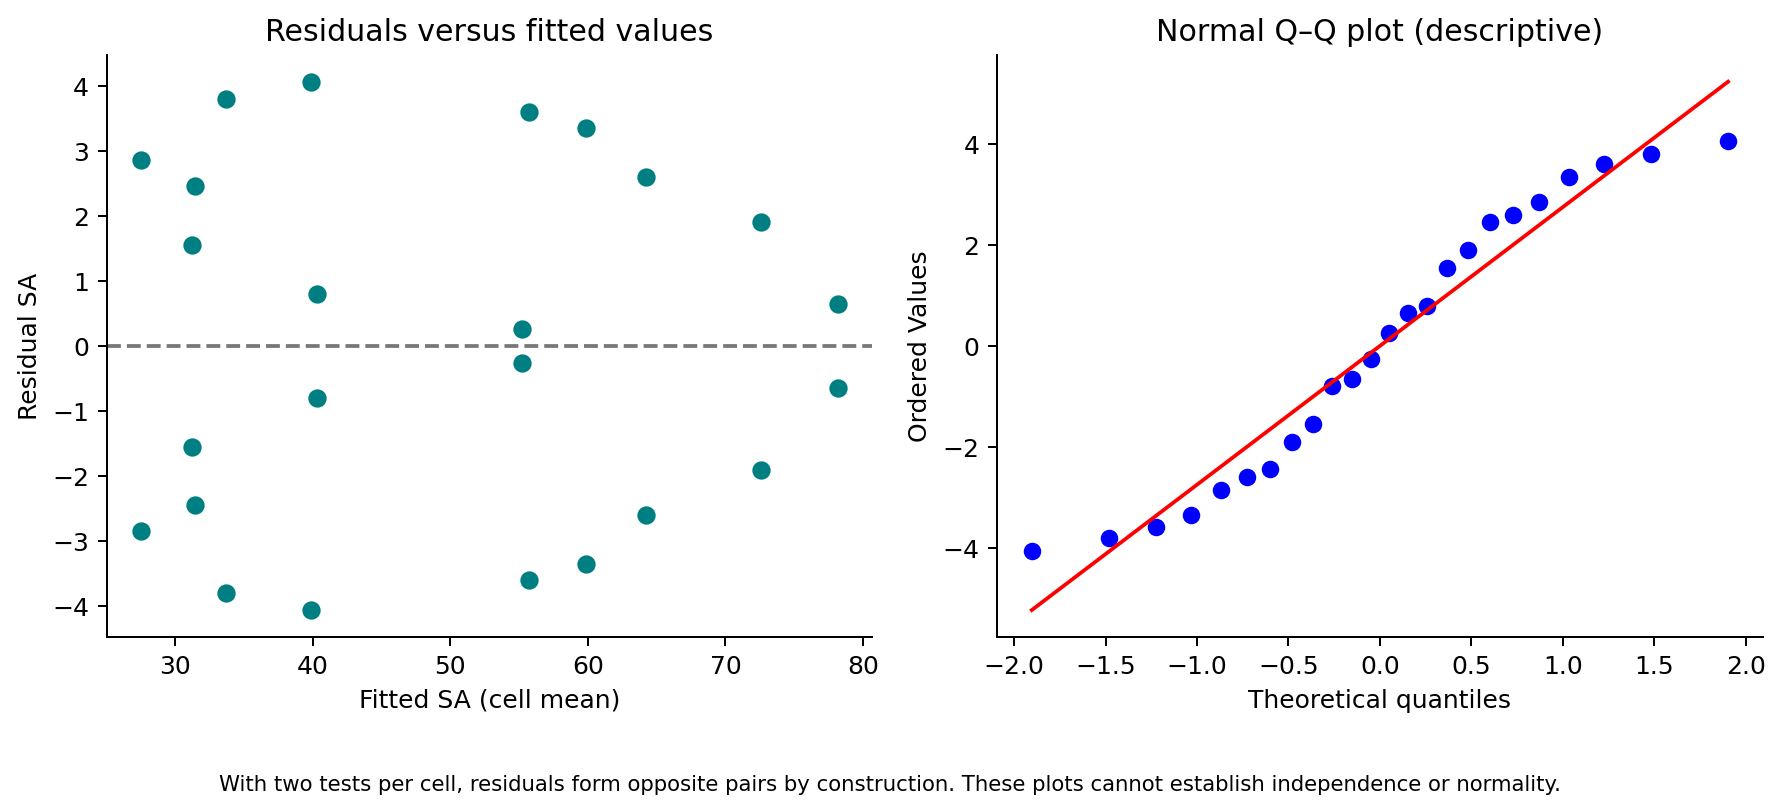

sd
Loading_level Carbon      Locality       
15            Disordered  IN        4.031
                          OUT       3.465
              Graphitized IN        2.192
                          OUT       5.742
              FCX-B       IN        5.374
                          OUT       1.131
40            Disordered  IN        5.091
                          OUT       0.919
              Graphitized IN        4.738
                          OUT       3.677
              FCX-B       IN        0.375
                          OUT       2.687

In [21]:
display(Image(filename=str(plot_path / 'residual_diagnostics.png')))
display(summary[['sd']].round(3))

## 22. Audit SA and inspect actual loading

If MA is in A/gPt and ECSA is in m²/gPt, the unit conversion gives `SA = 100 × MA / ECSA_CO` in µA/cm²Pt. The input columns are rounded and not perfectly consistent. We report the differences and keep the supplied SA; we do not assume a verified cause for every discrepancy.

Measured loading differs between nominally matched samples. This limits attributing a material difference to locality alone.

In [22]:
audit = validated[['Sample', 'Replicate', 'SA', 'SA_ratio_audit', 'SA_audit_difference']]
display(audit.reindex(audit.SA_audit_difference.abs().sort_values(ascending=False).index).head(6))
display(df[['Sample', 'Loading_level', 'Carbon', 'Locality', 'Loading']].drop_duplicates())

,Sample,Replicate,SA,SA_ratio_audit,SA_audit_difference
23,Pt_IN-40/FCX-B,2,54.97,54.535975,0.434025
22,Pt_IN-40/FCX-B,1,55.50,55.179090,0.320910
3,Pt_IN-15/FCX-Disordered,2,30.40,30.217670,0.182330
21,Pt_OUT-40/FCX-B,2,74.50,74.598930,-0.098930
6,Pt_IN-40/FCX-Disordered,1,52.10,52.004860,0.095140
1,Pt_OUT-15/FCX-Disordered,2,29.00,29.058442,-0.058442


,Sample,Loading_level,Carbon,Locality,Loading
0,Pt_OUT-15/FCX-Disordered,15,Disordered,OUT,14.60
2,Pt_IN-15/FCX-Disordered,15,Disordered,IN,16.08
4,Pt_OUT-40/FCX-Disordered,40,Disordered,OUT,45.01
6,Pt_IN-40/FCX-Disordered,40,Disordered,IN,42.05
8,Pt_OUT-15/FCX-Graphitized,15,Graphitized,OUT,12.20
10,Pt_IN-15/FCX-Graphitized,15,Graphitized,IN,16.08
12,Pt_OUT-40/FCX-Graphitized,40,Graphitized,OUT,41.20
14,Pt_IN-40/FCX-Graphitized,40,Graphitized,IN,38.40
16,Pt_OUT-15/FCX-B,15,FCX-B,OUT,12.30
18,Pt_IN-15/FCX-B,15,FCX-B,IN,18.80


## 23. See why an extra measured-loading coefficient is not identifiable

Measured loading is constant within each sample, so it is already represented by the full model's cell means. Adding its column gives 13 columns but rank remains 12. The additional coefficient cannot be independently identified. A software result from such a singular fit would not mean we successfully controlled measured loading.

A continuous-loading regression would ask a different question and require assumptions about response shape. Two loading settings per carbon/locality pair cannot validate linearity.

In [23]:
X = model.model.exog
X_plus_loading = np.column_stack([X, df['Loading']])
print('Original columns and rank:', X.shape[1], np.linalg.matrix_rank(X))
print('With measured loading:', X_plus_loading.shape[1], np.linalg.matrix_rank(X_plus_loading))
assert np.linalg.matrix_rank(X_plus_loading) == np.linalg.matrix_rank(X)

Original columns and rank: 12 12
With measured loading: 13 12


## 24. Test how the response scale changes the question

Raw SA models absolute changes. Log(SA) models relative/proportional changes. Interaction depends on scale: a constant ratio can correspond to an increasing absolute difference. This sensitivity analysis is not a search for smaller p-values.

The loading × locality raw p-value changes from about 0.0178 to 0.597, and the three-factor p-value changes from about 0.0284 to 0.166. The raw-scale interactions are not scale-invariant findings. Define the scientific question before choosing a scale.

In [24]:
log_model = ols(
    'np.log(SA) ~ C(Loading_level, Sum) * C(Carbon, Sum) * C(Locality, Sum)',
    data=df,
).fit()
log_anova = anova_lm(log_model, typ=3).drop(index='Intercept').rename(index=TERMS)
scale_comparison = pd.DataFrame({
    'raw_SA_p': anova['PR(>F)'],
    'log_SA_p': log_anova['PR(>F)'],
}).drop(index='Residual')
display(scale_comparison)

,raw_SA_p,log_SA_p
Loading,1.464782e-10,1.117537e-09
Carbon,4.786114e-01,1.759357e-01
Locality,1.554031e-05,1.550492e-04
Loading x Carbon,1.958890e-02,2.664839e-02
Loading x Locality,1.777931e-02,5.969428e-01
Carbon x Locality,2.021331e-01,6.394972e-01
Loading x Carbon x Locality,2.836070e-02,1.659270e-01


## 25. Reproduce all outputs with one command

Once the individual steps make sense, the reusable script performs validation, fitting, contrasts, plotting, and independent arithmetic checks. This is how a reader can reproduce the project without manually running each notebook cell. The function returns the fitted objects for further inspection.

From a terminal: `python src/analyze.py`. Output tables retain both raw and adjusted p-values, and the run metadata records software versions.

In [25]:
results = run_analysis(ROOT / 'data/catalyst_activity.csv', ROOT / 'outputs')
print('All calculations and independent checks completed.')
display(pd.DataFrame([results['info']]).drop(columns=['versions']))

All calculations and independent checks completed.


,observations,cells,electrode_tests_per_cell,scope,formula,residual_df,residual_ms,residual_sd,R_squared_descriptive,max_absolute_sa_ratio_discrepancy,design_rank,rank_after_adding_actual_loading
0,24,12,2,Conditional electrode-level analysis of these ...,"SA ~ C(Loading_level, Sum) * C(Carbon, Sum) * ...",12,13.856054,3.722372,0.975534,0.434025,12,12


## 26. Communicate the analysis

**What was done:** “We fitted a three-factor OLS model for specific activity with nominal loading, carbon support, and Pt locality, including all interactions. We used sum contrasts for Type III ANOVA, estimated interpretable mean differences and pointwise 95% confidence intervals, and reported Holm-adjusted p-values within stated comparison families.”

**What was found:** “The average nominal 40 − 15 wt% difference was 30.27 µA/cm²Pt. The OUT − IN gap varied across settings, increasing from 3.90 to 22.45 for Disordered carbon. The omnibus interaction patterns were exploratory after multiplicity adjustment and showed response-scale sensitivity.”

**What the design permits:** “The two replicates were independently prepared electrodes from the same catalyst batch. Inference describes differences among these tested samples relative to electrode error, rather than reproducibility across catalyst syntheses.”

ANOVA quantifies differences and uncertainty; it cannot identify a physical mechanism merely from carbon identity. The carbon main-effect test asks about averages, not whether carbon matters anywhere in the experiment. A nonsignificant test is not proof of equivalence.

## Questions to explain back

1. What is a cell, and why are there 12?
2. Why is OUT − IN = 22.45 an effect estimate but not an interaction by itself?
3. What does the denominator of F represent in this dataset?
4. Why can the average carbon effect be small while carbon-specific trends differ?
5. Which new measurements would allow inference across independent syntheses?

Answers and a fuller lesson are in [the companion guide](../docs/theory-and-walkthrough.md).

## Method references

- [NIST: multi-factor ANOVA](https://www.itl.nist.gov/div898/handbook/eda/section3/eda355.htm)
- [NIST: modeling designed experiments](https://www.itl.nist.gov/div898/handbook/pri/section4/pri43.htm)
- [NIST: residual assumptions](https://www.itl.nist.gov/div898/handbook/pri/section2/pri245.htm)
- [statsmodels: interactions and ANOVA](https://www.statsmodels.org/stable/examples/notebooks/generated/interactions_anova.html)
- [statsmodels: ANOVA API](https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html)
- [statsmodels: Holm and other multiple-testing methods](https://www.statsmodels.org/stable/generated/statsmodels.stats.multitest.multipletests.html)